In [35]:
import warnings
warnings.filterwarnings("ignore")

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [37]:
vocab_size = 10000 

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

In [38]:
max_len = 50

X_train = pad_sequences(X_train, maxlen=max_len)
X_test  = pad_sequences(X_test, maxlen=max_len)

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM,GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
def build_rnn():
    model = Sequential([
        Embedding(input_dim=10000, output_dim=64, input_length=50),
        SimpleRNN(64),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model

def build_lstm():
    model = Sequential([
        Embedding(input_dim=10000, output_dim=64, input_length=50),
        LSTM(64),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model
def build_gru():
    model = Sequential([
        Embedding(input_dim=10000, output_dim=128, input_length=50),
        GRU(128),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model
# Store models in list
models = [
    ("RNN", build_rnn()),
    ("LSTM", build_lstm()),
    ("GRU",build_gru() )
]

In [40]:
histories = {}

for name, model in models:
    print(f"\n Training {name} model...\n")
    
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    early_stop=EarlyStopping(
        monitor='val_loss',
          patience=3,
            restore_best_weights=True
    )
    history = model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=64,
        validation_split=0.1,
        callbacks=[early_stop]   
    )
    
    histories[name] = history


 Training RNN model...

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7075 - loss: 0.5348 - val_accuracy: 0.8032 - val_loss: 0.4266
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8592 - loss: 0.3318 - val_accuracy: 0.8012 - val_loss: 0.4387
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9319 - loss: 0.1814 - val_accuracy: 0.7888 - val_loss: 0.6217
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9756 - loss: 0.0696 - val_accuracy: 0.7684 - val_loss: 0.7443

 Training LSTM model...

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.7493 - loss: 0.4955 - val_accuracy: 0.8124 - val_loss: 0.3978
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8588 - loss: 0.3282 - val_accuracy: 0.8156 - val_loss: 0.3967
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8956 - loss: 0.2596 - val_accuracy: 0.7988 - val_loss: 0.4400
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/st

In [41]:
for name, model in models:
    print(f"\n Evaluating {name} model:")
    loss, acc = model.evaluate(X_test, y_test)
    print(f"{name} Accuracy: {acc:.4f}")


 Evaluating RNN model:
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8056 - loss: 0.4222
RNN Accuracy: 0.8056

 Evaluating LSTM model:
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8138 - loss: 0.4088
LSTM Accuracy: 0.8138

 Evaluating GRU model:
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8206 - loss: 0.3920
GRU Accuracy: 0.8206


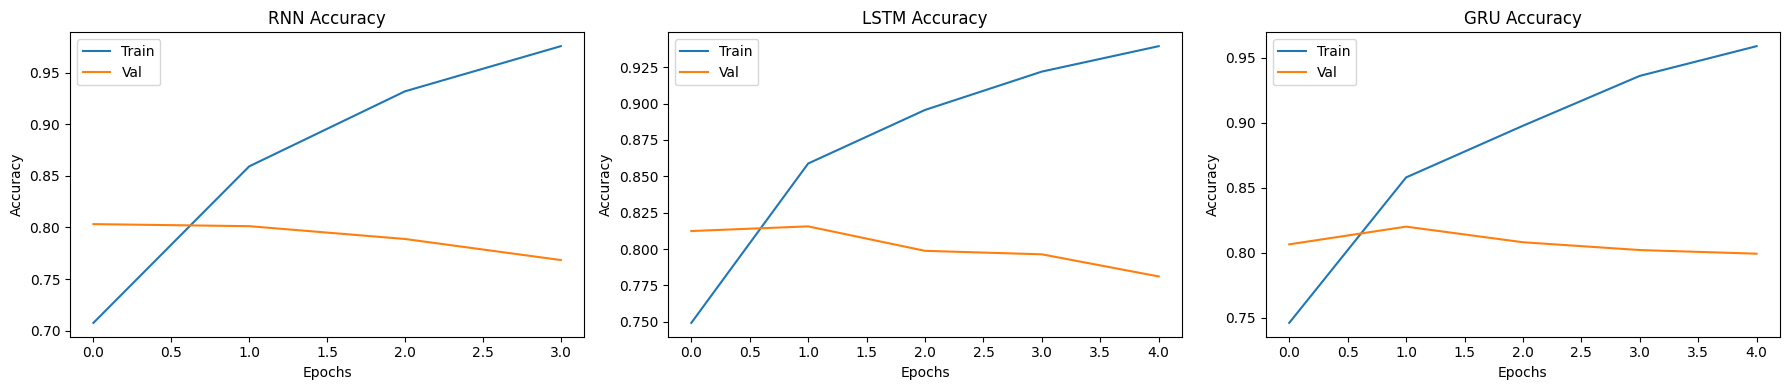

In [42]:
import matplotlib.pyplot as plt

n = len(histories)

plt.figure(figsize=(6*n, 4))  # adjust width dynamically

for i, (name, history) in enumerate(histories.items(), 1):
    plt.subplot(1, n, i)
    
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    
    plt.title(f'{name} Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(['Train', 'Val'])

plt.tight_layout()
plt.show()

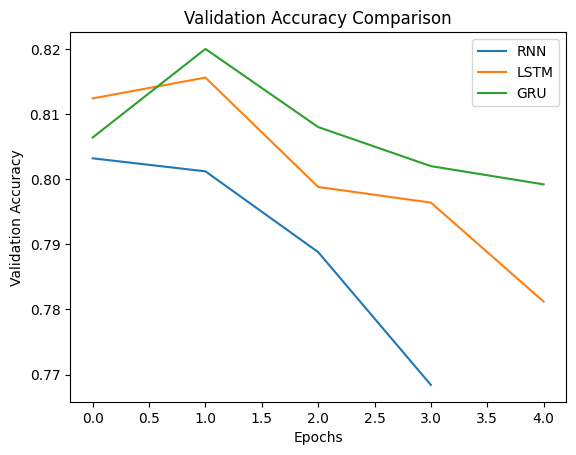

In [43]:
plt.figure()

for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)

plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()

plt.show()